# Assignment 3: LLMs and Machine Learning

---

## Statement of use of AI

I used Claude (Anthropic) to help me understand a few of the steps and to check my code for syntax errors after I had written a first version myself. I made sure to understand, challenge and fact check AI's output against the course content (lectures and exercises).

## Imports

I am importing all the libraries used throughout the notebook here in one place so that the imports are easy to find.

In [1]:
# General-purpose libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Library for talking to the Ollama server (the same OpenAI client we used in Exercise 5)
from openai import OpenAI

# Scikit-learn for machine learning (Task 3)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

## Task 0: Setting up Ollama

### a)

In [2]:
# Connecting to the local Ollama server using the OpenAI client
client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

# Helper function to send a prompt to a chosen model
def ask_llm(prompt, model):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

### b)

In [3]:
# Testing the small gemma3 model
MODEL_SMALL = "gemma3:270m"

print(ask_llm("In one short sentence, what is Python?", MODEL_SMALL))

Python is a versatile and popular programming language used for a wide range of applications.



### c)

In [4]:
# Testing the larger gemma3 model
MODEL_LARGE = "gemma3:4b"

print(ask_llm("In one short sentence, what is Python?", MODEL_LARGE))

Python is a versatile, high-level programming language known for its readability and wide range of applications.


## Task 1: Text classification with Ollama

In [5]:
# Load the emails dataset
emails = pd.read_csv("data/emails.csv")
emails

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000 EUR gift ...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,Q3 budget report attached please review by Friday
6,Reminder: Annual performance review scheduled ...
7,Updated draft of the manuscript comments welcome
8,Quick question about last week
9,Following up


### a)

In [6]:
# Function for classifying an email headline as spam, work, or unknown
def classify_email(headline, model):
    prompt = (
        "Classify the following email headline as one of: spam, work, unknown. "
        "Reply with only the category word.\n\n"
        f"Headline: {headline}"
    )
    answer = ask_llm(prompt, model)
    return answer.strip().lower().strip(".'\"")

### b)

In [7]:
# Classify with the 270m model
emails_small = emails.copy()
emails_small["classification_270m"] = emails_small["headline"].apply(
    lambda h: classify_email(h, MODEL_SMALL)
)
emails_small

,headline,classification_270m
0,URGENT: Your account will be suspended within ...,work
1,Congratulations! You have won a 1000 EUR gift ...,work
2,Hot singles in your area are waiting to meet y...,work
3,Re: Inheritance transfer of 4.5M USD pending y...,work
4,Meeting agenda for Thursday's project review,work
5,Q3 budget report attached please review by Friday,work
6,Reminder: Annual performance review scheduled ...,work
7,Updated draft of the manuscript comments welcome,work
8,Quick question about last week,unknown
9,Following up,work


### c)

In [8]:
# Classify with the 4b model
emails_large = emails.copy()
emails_large["classification_4b"] = emails_large["headline"].apply(
    lambda h: classify_email(h, MODEL_LARGE)
)
emails_large

,headline,classification_4b
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000 EUR gift ...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,Q3 budget report attached please review by Friday,work
6,Reminder: Annual performance review scheduled ...,work
7,Updated draft of the manuscript comments welcome,work
8,Quick question about last week,unknown
9,Following up,work


The 4b model worked much better. It got all the obvious spam right (rows 0–3) and all the obvious work emails right (rows 4–7). The 270m model labelled most of the spam as "work" and even returned "email" once, which is not one of the categories I asked for. Both models were inconsistent on the vague headlines (rows 8–11), but that is harder since those titles do not really say what the email is about.

### d)

In [9]:
# Run the classification 3 times with each model, store all results in one DataFrame
runs = emails.copy()

for i in range(1, 4):
    runs[f"270m_run{i}"] = runs["headline"].apply(lambda h: classify_email(h, MODEL_SMALL))

for i in range(1, 4):
    runs[f"4b_run{i}"] = runs["headline"].apply(lambda h: classify_email(h, MODEL_LARGE))

runs

,headline,270m_run1,270m_run2,270m_run3,4b_run1,4b_run2,4b_run3
0,URGENT: Your account will be suspended within ...,work,suspended,work,spam,spam,spam
1,Congratulations! You have won a 1000 EUR gift ...,work,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,work,work,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work,work,work,work
5,Q3 budget report attached please review by Friday,work,spam,spam,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work,work,work,work
7,Updated draft of the manuscript comments welcome,work,spam,work,work,work,work
8,Quick question about last week,spam,unknown,spam,unknown,work,unknown
9,Following up,spam,spam,spam,work,unknown,unknown


The 270m model gave different labels across the three runs and even invented categories I did not ask for (like "unspam", "uncategorized", "**urgent**", and "email"). The 4b model was much more consistent — most rows have the same label in all three runs. This happened because LLMs are probabilistic and the smaller model is less confident in its predictions.

## Task 2: Sentiment analysis with Ollama

In [10]:
# Load the news dataset
news = pd.read_csv("data/news.csv")
news

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,Aurelis Bank reports steady quarterly profit i...
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,Eurozone inflation cools to 2.1% easing pressu...
9,Rising interest rates weigh on Tessaro Real Es...


### a)

In [11]:
# Function for classifying topic and sentiment, returning JSON
def classify_news(headline, model):
    prompt = (
        "Classify the headline below.\n"
        "Topic must be one of: earnings, mergers, regulation, macroeconomics.\n"
        "Sentiment must be one of: positive, negative, neutral.\n"
        "Reply in JSON only, like this: {\"topic\": \"...\", \"sentiment\": \"...\"}\n\n"
        f"Headline: {headline}"
    )
    raw = ask_llm(prompt, model)

    # Sometimes the model wraps JSON in code fences, so I clean those off
    cleaned = raw.strip().strip("`")
    if cleaned.lower().startswith("json"):
        cleaned = cleaned[4:].strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        return {"topic": "unparsed", "sentiment": "unparsed"}

### b)

In [12]:
# Apply the function to all headlines and split the JSON into two columns
news_classified = news.copy()
results = news_classified["headline"].apply(lambda h: classify_news(h, MODEL_LARGE))

news_classified["topic"] = results.apply(lambda r: r["topic"])
news_classified["sentiment"] = results.apply(lambda r: r["sentiment"])

news_classified

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,Aurelis Bank reports steady quarterly profit i...,earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,Eurozone inflation cools to 2.1% easing pressu...,macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### c)

I gave the same 10 headlines to Gemini in the browser with the same instructions. The result was:

| # | Headline | Topic | Sentiment |
|---|---|---|---|
| 1 | Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | Earnings | Positive |
| 2 | Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | Earnings | Negative |
| 3 | Aurelis Bank reports steady quarterly profit in line with analyst expectations | Earnings | Neutral |
| 4 | Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | Mergers | Positive |
| 5 | Antitrust regulators block proposed merger between Solenta and Marvex Energy | Mergers | Negative |
| 6 | Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | Mergers | Neutral |
| 7 | New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | Regulation | Negative |
| 8 | Finnish FSA grants Norvik Capital expanded licence for cross-border operations | Regulation | Positive |
| 9 | Eurozone inflation cools to 2.1% easing pressure on Drava Holdings borrowing costs | Macroeconomics | Positive |
| 10 | Rising interest rates weigh on Tessaro Real Estate as financing costs climb | Macroeconomics | Negative |

(Note: Gemini numbers from 1, pandas from 0, so Gemini #3 corresponds to row 2 in my DataFrame.)

The two models agreed on 7 out of 10 headlines. The differences were:
- Aurelis Bank steady profit: gemma3 said positive, Gemini said neutral (Gemini fits better since "in line with expectations" is neutral).
- Veridyne acquires Trantec: gemma3 said neutral, Gemini said positive (Gemini fits better since acquisitions are usually positive news).
- Antitrust block merger: gemma3 said regulation, Gemini said mergers (both make sense — the headline involves regulators and a merger).

Gemini's labels match my own judgement more often, which makes sense since it is a much larger model than the local 4b gemma3.

## Task 3: Supervised machine learning

### a)

In [13]:
# Load the bank-additional dataset (semicolon-separated)
bank = pd.read_csv("data/bank-additional.csv", sep=";")

print("Shape:", bank.shape)
bank.head()

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [14]:
# Data types and non-null counts
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [15]:
# Summary statistics for the numeric columns
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [16]:
# Check for missing values
bank.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [17]:
# Several categorical columns contain "unknown" instead of missing values
for col in bank.select_dtypes(include="object").columns:
    n_unknown = (bank[col] == "unknown").sum()
    if n_unknown > 0:
        print(col, ":", n_unknown)

job : 39
marital : 11
education : 167
default : 803
housing : 105
loan : 105


In [18]:
# Check the balance of the target variable y
bank["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

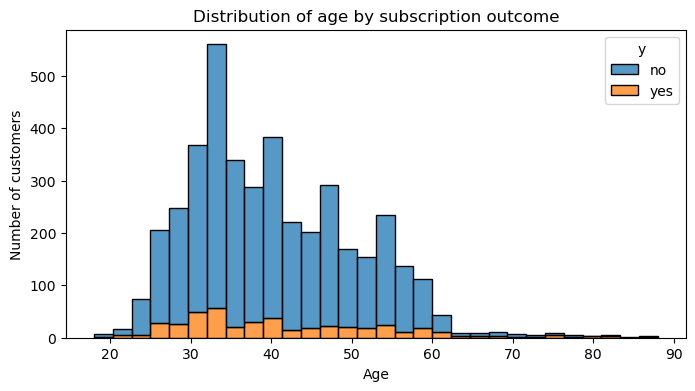

In [19]:
# Distribution of age, split by subscription outcome
plt.figure(figsize=(8, 4))
sns.histplot(data=bank, x="age", hue="y", bins=30, multiple="stack")
plt.title("Distribution of age by subscription outcome")
plt.xlabel("Age")
plt.ylabel("Number of customers")
plt.show()

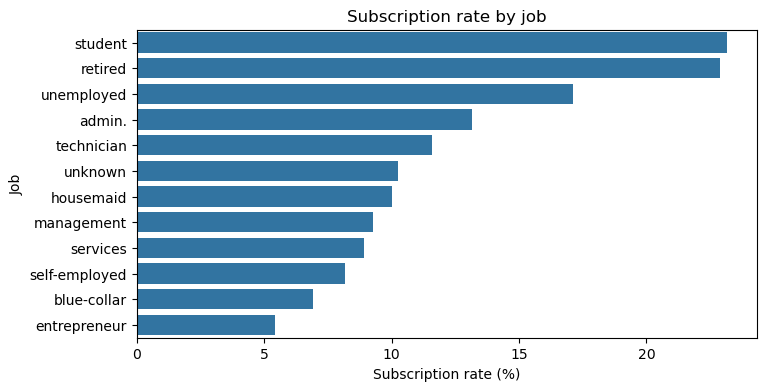

In [20]:
# Subscription rate by job
subscription_by_job = bank.groupby("job")["y"].apply(lambda s: (s == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=subscription_by_job.values, y=subscription_by_job.index)
plt.title("Subscription rate by job")
plt.xlabel("Subscription rate (%)")
plt.ylabel("Job")
plt.show()

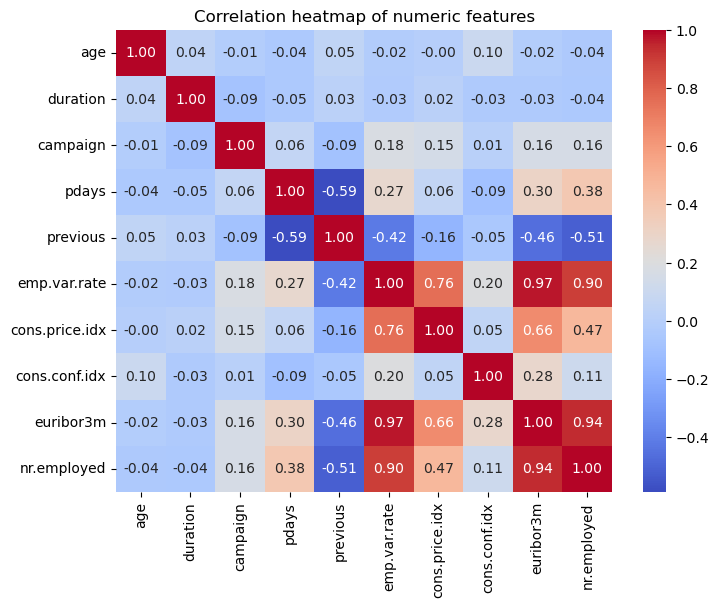

In [21]:
# Correlations between numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(bank.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap of numeric features")
plt.show()

- 4119 rows, 21 columns.
- Target y is imbalanced: 3668 "no" vs 451 "yes" (around 11% subscribed).
- No NaN values, but 6 categorical columns have "unknown" instead — most in default (803).
- Most customers are between 25 and 55 years old.
- Students and retired customers subscribe most often (around 23%), entrepreneurs and blue-collar least (around 5–7%).
- emp.var.rate, euribor3m and nr.employed are highly correlated with each other.

### b)

In [22]:
# Make a copy and drop duration (the dataset description says it should not be used for prediction)
df = bank.copy()
df = df.drop(columns=["duration"])

# Encode target as 1 = yes, 0 = no
df["y"] = df["y"].map({"yes": 1, "no": 0})

In [23]:
# One-hot encode all categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
df.head()

Shape after one-hot encoding: (4119, 53)


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,0,...,True,False,False,False,False,False,False,False,True,False
1,39,4,999,0,1.1,93.994,-36.4,4.855,5191.0,0,...,True,False,False,False,False,False,False,False,True,False
2,25,1,999,0,1.4,94.465,-41.8,4.962,5228.1,0,...,False,False,False,False,False,False,False,True,True,False
3,38,3,999,0,1.4,94.465,-41.8,4.959,5228.1,0,...,False,False,False,False,False,False,False,False,True,False
4,47,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,0,...,False,True,False,False,True,False,False,False,True,False


In [24]:
# Standardise the numeric columns
numeric_cols = ["age", "campaign", "pdays", "previous",
                "emp.var.rate", "cons.price.idx", "cons.conf.idx",
                "euribor3m", "nr.employed"]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.980752,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,0,...,True,False,False,False,False,False,False,False,True,False
1,-0.107991,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,0,...,True,False,False,False,False,False,False,False,True,False
2,-1.465619,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,0,...,False,False,False,False,False,False,False,True,True,False
3,-0.204965,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,0,...,False,False,False,False,False,False,False,False,True,False
4,0.667795,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,0,...,False,True,False,False,True,False,False,False,True,False


### c)

This is a classification task because the target y has two discrete values (yes/no), not a continuous one.

I chose three algorithms from scikit-learn:
- K-nearest neighbors: simple non-parametric algorithm, good as a baseline.
- Random forest: ensemble method that handles mixed data types well and rarely overfits.
- SVM: works well for binary classification and handles the many one-hot-encoded features.

In [25]:
# Split features and target
y = df["y"]
X = df.drop(columns=["y"])

# 80/20 split first to get the test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 75/25 split of the rest to get train and validation (resulting in 60/20/20 overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train size:     ", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:      ", X_test.shape[0])

Train size:      2471
Validation size: 824
Test size:       824


In [26]:
# Helper function to print the four metrics in the same way for every model
def print_scores(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print()

In [27]:
# KNN: train default model first, then grid search for best n_neighbors and weights
knn_basic = KNeighborsClassifier()
knn_basic.fit(X_train, y_train)
print_scores("KNN (default)", y_val, knn_basic.predict(X_val))

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"]
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="f1", n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print_scores("KNN (tuned)", y_val, grid_knn.best_estimator_.predict(X_val))

--- KNN (default) ---
Accuracy:  0.8932
Precision: 0.5294
Recall:    0.2000
F1-score:  0.2903

Best KNN parameters: {'n_neighbors': 3, 'weights': 'uniform'}
--- KNN (tuned) ---
Accuracy:  0.8859
Precision: 0.4615
Recall:    0.2667
F1-score:  0.3380



In [28]:
# Random forest: train default first, then grid search
rf_basic = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_basic.fit(X_train, y_train)
print_scores("Random forest (default)", y_val, rf_basic.predict(X_val))

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid_rf, cv=5, scoring="f1", n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best random forest parameters:", grid_rf.best_params_)
print_scores("Random forest (tuned)", y_val, grid_rf.best_estimator_.predict(X_val))

--- Random forest (default) ---
Accuracy:  0.9005
Precision: 0.6538
Recall:    0.1889
F1-score:  0.2931

Best random forest parameters: {'bootstrap': True, 'max_depth': 5, 'n_estimators': 100}
--- Random forest (tuned) ---
Accuracy:  0.8677
Precision: 0.4159
Recall:    0.5222
F1-score:  0.4631



In [29]:
# SVM: train default first, then grid search
svm_basic = SVC(random_state=42, class_weight="balanced")
svm_basic.fit(X_train, y_train)
print_scores("SVM (default)", y_val, svm_basic.predict(X_val))

param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(
    SVC(random_state=42, class_weight="balanced"),
    param_grid_svm, cv=5, scoring="f1", n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print("Best SVM parameters:", grid_svm.best_params_)
print_scores("SVM (tuned)", y_val, grid_svm.best_estimator_.predict(X_val))

--- SVM (default) ---
Accuracy:  0.8434
Precision: 0.3617
Recall:    0.5667
F1-score:  0.4416

Best SVM parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
--- SVM (tuned) ---
Accuracy:  0.8556
Precision: 0.3876
Recall:    0.5556
F1-score:  0.4566



In [30]:
# Save the best estimator from each algorithm for use in tasks d) and e)
best_models = {
    "KNN": grid_knn.best_estimator_,
    "Random forest": grid_rf.best_estimator_,
    "SVM": grid_svm.best_estimator_
}

After tuning, random forest had the best F1 on the validation set (0.46), with SVM very close behind (0.46) and KNN clearly worse (0.34). KNN had the lowest recall, meaning it misses many of the customers who would actually subscribe. SVM had the highest recall (0.56) but lower precision than random forest. The accuracy is similar for all three models, but that is not very useful here since the dataset is imbalanced (around 89% "no").

### d)

In [31]:
# Compare the F1 from the single validation split with 5-fold cross-validation
# CV is run on X_temp/y_temp (train+validation combined) so the test set stays untouched
comparison_rows = []

for name, model in best_models.items():
    val_f1 = f1_score(y_val, model.predict(X_val))
    cv_scores = cross_val_score(model, X_temp, y_temp, cv=5, scoring="f1", n_jobs=-1)
    comparison_rows.append({
        "Model": name,
        "Validation F1": round(val_f1, 4),
        "CV F1 (mean)": round(cv_scores.mean(), 4),
        "CV F1 (std)": round(cv_scores.std(), 4)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Validation F1,CV F1 (mean),CV F1 (std)
0,KNN,0.3380,0.3207,0.0419
1,Random forest,0.4631,0.4744,0.0424
2,SVM,0.4566,0.4333,0.0744


The cross-validation scores are mostly close to the single validation scores, but for SVM the validation F1 (0.46) was higher than the 5-fold CV mean (0.43), so the single split was a bit optimistic. SVM also has a much higher std across folds (0.074) than the other two models (around 0.042), meaning it is less stable depending on which rows end up in the held-out fold.

Cross-validation performs better as an evaluation method because the single split depends on which rows happen to land in the validation set, while CV averages over 5 different splits and gives a less optimistic estimate. The downside is that it takes longer to run.

### e)

In [32]:
# Evaluate each best model on the test set
final_rows = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    final_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4)
    })

final_df = pd.DataFrame(final_rows)
final_df

,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.8835,0.4286,0.2000,0.2727
1,Random forest,0.8799,0.4545,0.5000,0.4762
2,SVM,0.8738,0.4375,0.5444,0.4851


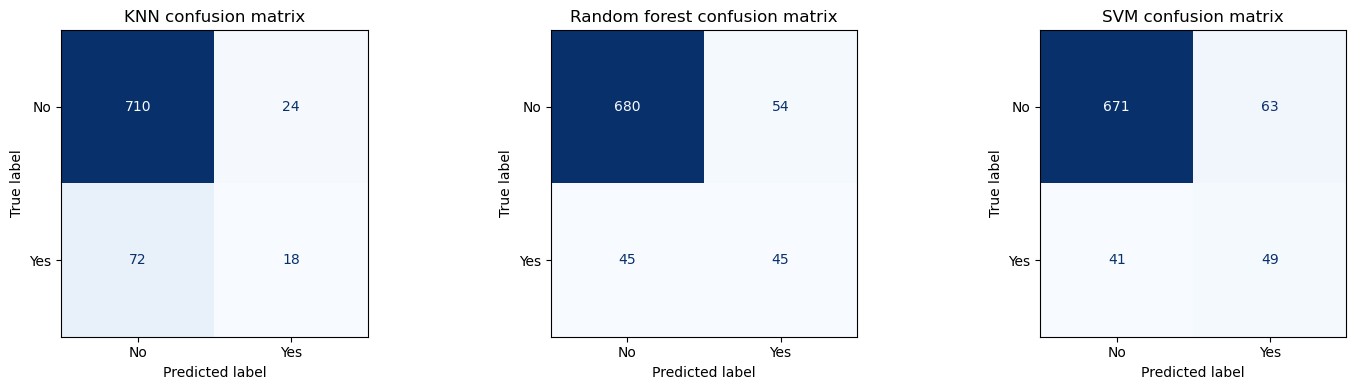

In [33]:
# Confusion matrices for the three models on the test set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} confusion matrix")

plt.tight_layout()
plt.show()

On the test set SVM had the best F1-score (0.49) and the highest recall (0.54), meaning it correctly identified 49 out of the 90 actual subscribers. Random forest was close behind on F1 (0.48) but caught fewer subscribers (45 out of 90). KNN was clearly the worst, only catching 18 out of 90 (recall of just 0.20).

Accuracy is similar for all three models (around 87-88%), but it is misleading here because the dataset is imbalanced — a model that always predicts "no" would already get around 89% accuracy without learning anything. F1 and recall are more useful metrics for this task.

In a marketing setting the bank wants to identify as many likely subscribers as possible, so recall matters more than precisi